In [ ]:
"""
Plot objective-function curves for each structural parameter.

This script:
1. Simulates data using the true parameters
2. Builds the estimation dataset
3. Constructs observed shares and delta indexing objects
4. Evaluates the negative log-likelihood over a grid for each parameter
5. Plots the objective curve with a vertical line at the true value

Expected project structure
--------------------------
project/
├─ src/
│  ├─ simulate.py
│  ├─ build_dataset.py
│  └─ estimation.py
└─ scripts/
   └─ plot_objective_curves.py
"""

In [46]:
from pathlib import Path
import importlib
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import logsumexp

In [48]:
# ---------------------------------------------------------------------
# Make src importable
# ---------------------------------------------------------------------

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

import src.simulate, src.build_dataset, src.estimation
importlib.reload(src.simulate)
importlib.reload(src.build_dataset)
importlib.reload(src.estimation)

from src.simulate import simulate_data
from src.build_dataset import build_estimation_data
from src.estimation import halton_normal_draws, negative_log_likelihood


In [17]:
def prepare_share_inputs(estimation_df, outside_id=None):
    """
    Build observed shares and delta-indexing objects for estimation.
    """
    chosen = (
        estimation_df.loc[estimation_df["choice"] == 1]
        .groupby(["time", "ran_rep_id"])["hh_id"]
        .nunique()
        .rename("chosen_count")
        .reset_index()
    )

    totals = (
        estimation_df.groupby("time")["hh_id"]
        .nunique()
        .rename("total_count")
        .reset_index()
    )

    share_obs = (
        chosen.merge(totals, on="time", how="left")
        .assign(market_share=lambda d: d["chosen_count"] / d["total_count"])
        .sort_values(["time", "ran_rep_id"])
        .reset_index(drop=True)
    )

    if outside_id is not None:
        share_obs = share_obs.loc[share_obs["ran_rep_id"] != outside_id].copy()

    s_obs = share_obs["market_share"].to_numpy()

    if outside_id is not None:
        mask = estimation_df["ran_rep_id"] != outside_id
    else:
        mask = np.ones(len(estimation_df), dtype=bool)

    keys = pd.MultiIndex.from_frame(estimation_df.loc[mask, ["time", "ran_rep_id"]])
    codes, uniques = pd.factorize(keys, sort=True)

    estimation_df = estimation_df.copy()
    estimation_df.loc[mask, "jt_code"] = codes.astype("int32")
    estimation_df.loc[~mask, "jt_code"] = -1

    jt_code = estimation_df["jt_code"].to_numpy().astype(np.intp, copy=False)
    mask_in = jt_code != -1
    M = len(uniques)

    return {
        "estimation_df": estimation_df,
        "share_obs": share_obs,
        "s_obs": s_obs,
        "jt_code": jt_code,
        "mask_in": mask_in,
        "M": M,
    }

Part I: Simulate the Data

In [18]:
true_params = {
    "theta_p": -0.3,
    "sigma": 0.5,
    "gamma_A": -1,
    "gamma_R": -2,
}

sim = simulate_data(
    seed_1=42,
    seed_2=123,
    n_nonmover=5000,
    n_periods=10,
    n_retailers=6,
    n_mover_per_period=600,
    sigma_true=true_params["sigma"],
    theta_p_true=true_params["theta_p"],
    gamma_A_true=true_params["gamma_A"],
    gamma_R_true=true_params["gamma_R"],
)

retailers = sim["retailers"]
retailer_time_df = sim["retailer_time_df"]
panel_df = sim["panel_df"]
arep_id = sim["meta"]["arep_id"]
outside_id = sim["meta"]["outside_id"]

print("Simulation complete.")
print(f"Number of retailers: {len(retailers)}")
print(f"Number of panel rows: {len(panel_df):,}")
display(panel_df.head())
display(retailer_time_df.head())

Simulation complete.
Number of retailers: 6
Number of panel rows: 56,000


,hh_id,time,mover,prev_retailer,stay_price_at_t,chosen_retailer,price_used,remaining_contract_end_of_t
0,nonmover_0,0,0,r0,8.080118,r0,8.080118,0
1,nonmover_1,0,0,r0,8.080118,r0,8.080118,0
2,nonmover_2,0,0,r0,8.080118,r0,8.080118,0
3,nonmover_3,0,0,r0,8.080118,r0,8.080118,0
4,nonmover_4,0,0,r0,8.080118,r4,11.821258,11


,time,ran_rep_id,delta,price_offer
0,0,r0,3.341087,8.080118
1,0,r1,2.782402,10.348572
2,0,r2,2.970431,11.007169
3,0,r3,2.893842,9.679912
4,0,r4,2.995919,11.821258


Part II: Construct the Estimation Dataset

In [19]:
bundle = build_estimation_data(
    panel_df=panel_df,
    retailer_time_df=retailer_time_df,
    retailers=retailers,
    arep_id=arep_id,
    outside_id=outside_id,
)

estimation_df = bundle["estimation_df"]

print("Estimation dataset complete.")
print(f"Expanded rows: {bundle['n_rows']:,}")
print(f"Choice occasions: {bundle['n_groups']:,}")
print(f"Households: {bundle['n_households']:,}")
display(estimation_df)

Estimation dataset complete.
Expanded rows: 336,000
Choice occasions: 56,000
Households: 11,000


,hh_id,time,mover,prev_retailer,stay_price_at_t,chosen_retailer,price_used,remaining_contract_end_of_t,ran_rep_id,delta,price_offer,AREP,sc_AREP,sc_REP,real_price,choice,hh_idx
0,nonmover_0,0,0,r0,8.080118,r0,8.080118,0,r0,3.341087,8.080118,1,0,0,8.080118,1,0
1,nonmover_0,0,0,r0,8.080118,r0,8.080118,0,r1,2.782402,10.348572,0,1,0,10.348572,0,0
2,nonmover_0,0,0,r0,8.080118,r0,8.080118,0,r2,2.970431,11.007169,0,1,0,11.007169,0,0
3,nonmover_0,0,0,r0,8.080118,r0,8.080118,0,r3,2.893842,9.679912,0,1,0,9.679912,0,0
4,nonmover_0,0,0,r0,8.080118,r0,8.080118,0,r4,2.995919,11.821258,0,1,0,11.821258,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
335995,mover_9_599,9,1,None,NaN,r5,0.000000,0,r1,2.066279,10.922755,0,0,0,10.922755,0,10999
335996,mover_9_599,9,1,None,NaN,r5,0.000000,0,r2,2.197938,8.873677,0,0,0,8.873677,0,10999
335997,mover_9_599,9,1,None,NaN,r5,0.000000,0,r3,2.046205,11.780863,0,0,0,11.780863,0,10999
335998,mover_9_599,9,1,None,NaN,r5,0.000000,0,r4,2.220551,9.256125,0,0,0,9.256125,0,10999


In [20]:
##compute retailers' share
share_inputs = prepare_share_inputs(estimation_df, outside_id=outside_id)

estimation_df = share_inputs["estimation_df"]
s_obs = share_inputs["s_obs"]
jt_code = share_inputs["jt_code"]
mask_in = share_inputs["mask_in"]
M = share_inputs["M"]

print("Share inputs prepared.")
print(f"Number of delta terms (M): {M}")
print(f"Length of observed share vector: {len(s_obs)}")
display(share_inputs["share_obs"]['market_share'].to_numpy())

Share inputs prepared.
Number of delta terms (M): 50
Length of observed share vector: 50


array([0.59285714, 0.07714286, 0.07160714, 0.09982143, 0.06160714,
       0.36607143, 0.18160714, 0.07232143, 0.13160714, 0.08642857,
       0.13125   , 0.20857143, 0.13589286, 0.125     , 0.16142857,
       0.2       , 0.16303571, 0.14232143, 0.16160714, 0.20803571,
       0.16482143, 0.16732143, 0.13232143, 0.14482143, 0.21696429,
       0.15339286, 0.13642857, 0.14964286, 0.17535714, 0.18107143,
       0.13035714, 0.23892857, 0.13017857, 0.15660714, 0.15732143,
       0.15642857, 0.2025    , 0.12946429, 0.16553571, 0.17339286,
       0.21160714, 0.15017857, 0.08321429, 0.1475    , 0.11053571,
       0.09857143, 0.12678571, 0.14589286, 0.10785714, 0.14589286])

In [34]:
#draw unobserved individual shock v_i for each household
v_base = halton_normal_draws(bundle["n_households"],n_draws = 50, seed_3=35, clip=1e-12)
#take initial guess of retailer-time mean utility delta_jt
rng = np.random.default_rng(seed = 421)
delta_state = {"value": rng.normal(0.0, 0.1, size=M)}

print("Estimation inputs ready.")
print(f"v_base shape: {v_base.shape}")
print(f"Initial delta shape: {delta_state['value'].shape}")

Estimation inputs ready.
v_base shape: (11000, 50)
Initial delta shape: (50,)


Part III: Plot the Objective Function for a Selected Parameter

In [38]:
##Compute the values of the objective function at each value of the selected parameter on the grid
def evaluate_one_parameter_curve(
    param_name,
    true_params,
    bundle,
    jt_code,
    mask_in,
    M,
    s_obs,
    v_base,
    outside_id,
    delta,
    verbose_cm=True,
):
    obj_values = []
    grid = param_grids[param_name]
    for val in grid:
        params = {
            "theta_p": true_params["theta_p"],
            "sigma": true_params["sigma"],
            "gamma_A": true_params["gamma_A"],
            "gamma_R": true_params["gamma_R"],
        }
        params[param_name] = val

        print("\n" + "=" * 70)
        print(f"Evaluating {param_name} = {val:.4f}")
        print(f"Parameters: {params}")

        obj = negative_log_likelihood(
            [
                params["theta_p"],
                params["sigma"],
                params["gamma_A"],
                params["gamma_R"],
            ],
            bundle,
            jt_code,
            mask_in,
            s_obs,
            delta_state,
            v_base,
            outside_id=outside_id,
            cm_max_iter=5000,
            cm_tol= 1e-7,
            block_size=10,
            n_jobs=5,
            verbose_cm=False
        )

        print(f"Objective value: {obj:.6f}")
        obj_values.append(obj)

    return np.array(obj_values)

In [ ]:
param_grids = {
    "theta_p": np.arange(-0.6, 0.05, 0.05),
    "sigma": np.arange(0.05, 0.8, 0.05),
    "gamma_A": np.arange(-5.0, 2.0, 0.5),
    "gamma_R": np.arange(-5.0, 2.0, 0.5),
}
pretty_labels = {
    "theta_p": r"$\theta_p$",
    "sigma": r"$\sigma$",
    "gamma_A": r"$\gamma_A$",
    "gamma_R": r"$\gamma_R$",
}

In [ ]:
#Show ONE example
param_name = "theta_p"

obj_values = evaluate_one_parameter_curve(
    param_name=param_name,
    true_params=true_params,
    bundle=bundle,
    jt_code=jt_code,
    mask_in=mask_in,
    M=M,
    s_obs=s_obs,
    v_base=v_base,
    outside_id=outside_id,
    delta = delta_state,
    verbose_cm=True
)

plt.figure(figsize=(8, 5))
plt.plot(param_grids[param_name], obj_values, marker="o")
plt.axvline(true_params[param_name], linestyle="--", label="True value")
plt.xlabel(pretty_labels[param_name])
plt.ylabel("Negative average log-likelihood")
plt.title(f"Objective curve for {pretty_labels[param_name]}")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

To improve runtime, we load precomputed objective function values by default.  
Set `use_cache = False` to recompute the results from scratch.

In [ ]:
import pickle
CACHE_DIR = Path("results")
CACHE_DIR.mkdir(exist_ok=True)

cache_file = CACHE_DIR / "objective_curves.pkl"

In [70]:
use_cache = True
if cache_file.exists() and use_cache:
    with open(cache_file, "rb") as f:
        obj_values_dict = pickle.load(f)
    print("Loaded cached results.")
else:
    print("Computing objective curves...")

    obj_values_dict = {
        param_name: evaluate_one_parameter_curve(
            param_name=param_name,
            grid=param_grids[param_name],
            true_params=true_params,
            bundle=bundle,
            jt_code=jt_code,
            mask_in=mask_in,
            M=M,
            s_obs=s_obs,
            v_base=v_base,
            outside_id=outside_id,
            delta = delta_state,
            verbose_cm=False,
        )
        for param_name in ["theta_p", "sigma", "gamma_A", "gamma_R"]
    }

    with open(cache_file, "wb") as f:
        pickle.dump(obj_values_dict, f)

    print("Computed and saved results.")

Loaded cached results.


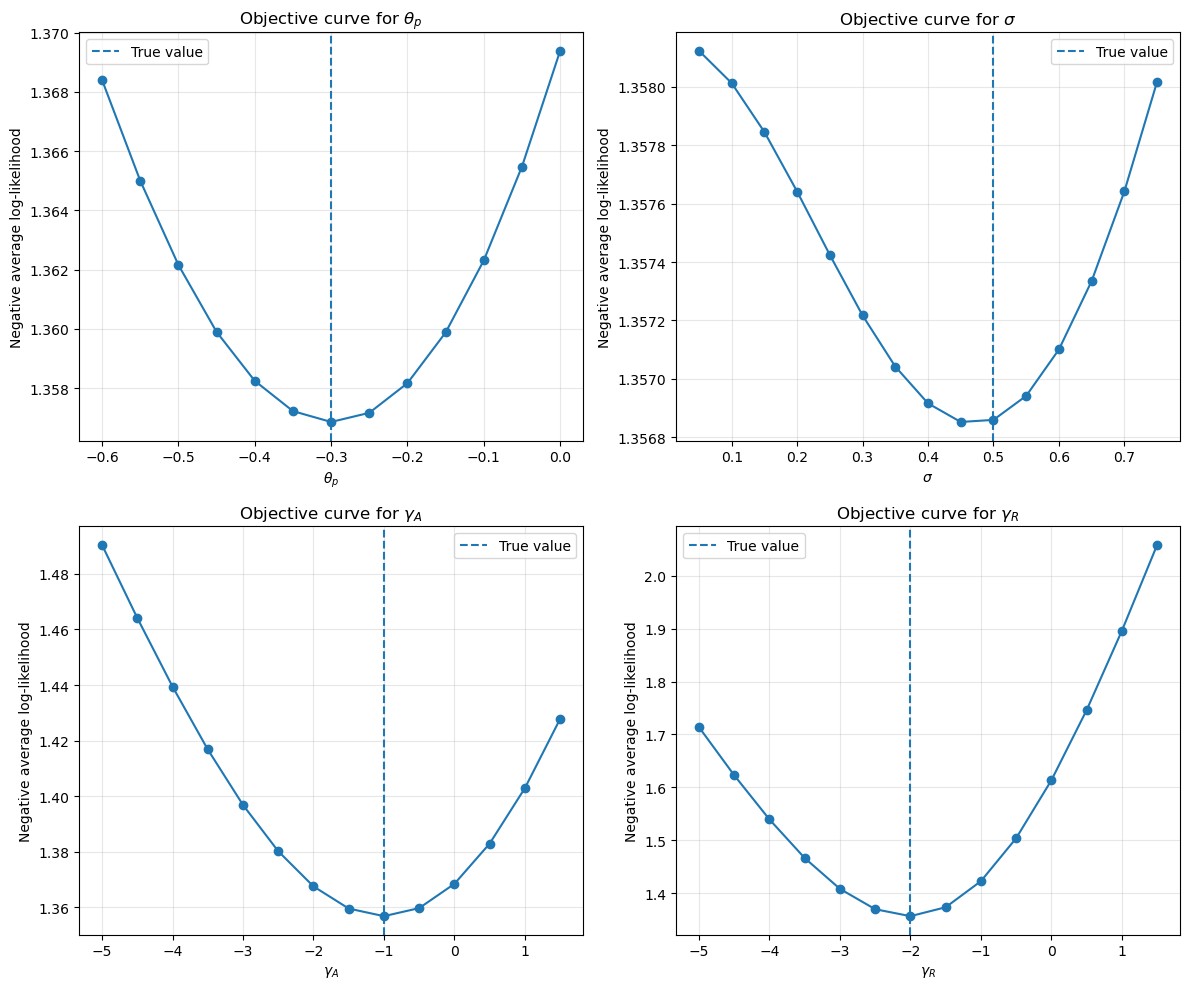

In [74]:

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (param_name, obj_values) in enumerate(obj_values_dict.items()):
    ax = axes[i]
    ax.plot(param_grids[param_name], obj_values, marker="o")
    ax.axvline(true_params[param_name], linestyle="--", label="True value")
    ax.set_xlabel(pretty_labels[param_name])
    ax.set_ylabel("Negative average log-likelihood")
    ax.set_title(f"Objective curve for {pretty_labels[param_name]}")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "objective_curves.png", dpi=300, bbox_inches="tight")
plt.show()

Part IV: Estimate the Model

In [57]:
def objective(params):
    """
    Wrapper around the negative log-likelihood.
    """
    return negative_log_likelihood(
        params=params,
        data=bundle,
        jt_code=jt_code,
        mask_in=mask_in,
        s_obs=s_obs,
        delta_state=delta_state,
        v_base_draws=v_base,
        outside_id=outside_id,
        cm_max_iter=5000,
        cm_tol=1e-7,
        block_size=10,
        n_jobs=5,
        verbose_cm=False,
    )

In [58]:
from scipy.optimize import minimize

init_params = np.array([-1.0, 1.0, 0.0, 0.0])

bounds = [
    (None, 0.0),   # theta_p
    (0.0, None),   # sigma
    (None, 0.0),   # gamma_A
    (None, 0.0),   # gamma_R
]

# Track optimizer progress
iteration_counter = {"count": 0}

def callback(xk):
    """
    Print parameter values after each optimizer iteration.
    """
    iteration_counter["count"] += 1
    current_obj = objective(xk)
    print(
        f"Iteration {iteration_counter['count']:3d}: "
        f"objective = {current_obj:.6f}, "
        f"theta_p = {xk[0]:.4f}, "
        f"sigma = {xk[1]:.4f}, "
        f"gamma_A = {xk[2]:.4f}, "
        f"gamma_R = {xk[3]:.4f}"
    )



To reduce runtime, the estimation results are loaded from a cached file by default.  
Set `use_estimation_cache = False` to rerun the optimization.

In [64]:
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

estimation_file = RESULTS_DIR / "estimation_result.pkl"

use_estimation_cache = True
if estimation_file.exists() and use_estimation_cache:
    with open(estimation_file, "rb") as f:
        result = pickle.load(f)
    print("Loaded cached estimation result.")
else:
    print("Running estimation...")

    result = minimize(
        fun=objective,
        x0=init_params,
        method="L-BFGS-B",
        bounds=bounds,
        jac=None,
        callback=callback,
        options={
            "eps": 1e-3,
            "disp": True,
            "maxiter": 10000,
            "gtol": 1e-8,
            "ftol": 1e-13,
        },
    )

    with open(estimation_file, "wb") as f:
        pickle.dump(result, f)

    print("Estimation complete and saved.")

Loaded cached estimation result.


In [65]:
print("\nOptimization Summary")
print("-------------------")
print("Success:", result.success)
print("Message:", result.message)
print("Estimated parameters:", result.x)
print("Objective value:", result.fun)


Optimization Summary
-------------------
Success: True
Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Estimated parameters: [-0.29495102  0.45853884 -1.01506015 -2.02310105]
Objective value: 1.3568117213222075


Part V: Compare True and Estimated Parameters

The table below compares the true parameters used in the data-generating process with the estimated parameters obtained from the model. Small estimation errors indicate that the procedure successfully recovers the underlying parameters.

In [66]:
# Build comparison table
results_table = pd.DataFrame({
    "Parameter": ["theta_p", "sigma", "gamma_A", "gamma_R"],
    "True Value": [
        true_params["theta_p"],
        true_params["sigma"],
        true_params["gamma_A"],
        true_params["gamma_R"],
    ],
    "Estimated Value": result.x,
})

# Compute error
results_table["Error"] = results_table["Estimated Value"] - results_table["True Value"]
results_table["Abs Error"] = results_table["Error"].abs()

# Pretty display
results_table.style.format({
    "True Value": "{:.4f}",
    "Estimated Value": "{:.4f}",
    "Error": "{:.4f}",
    "Abs Error": "{:.4f}",
})

,Parameter,True Value,Estimated Value,Error,Abs Error
0,theta_p,-0.3000,-0.2950,0.0050,0.0050
1,sigma,0.5000,0.4585,-0.0415,0.0415
2,gamma_A,-1.0000,-1.0151,-0.0151,0.0151
3,gamma_R,-2.0000,-2.0231,-0.0231,0.0231
